<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/lstm_PerformanceChecking/1lstm_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ================== IMPORTS ==================
import os
import random
import itertools
from datetime import timedelta, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ================== CONFIG / CONSTANTS ==================
# Suppress TF logs for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Path to Excel file
INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

# Train/test split settings
TEST_SET_DAYS = 60      # last 60 days reserved for test
VAL_DAYS = 90           # validation fold length
N_SPLITS = 2            # number of CV folds
N_TIMESTEPS = 7         # LSTM sequence window
MAPE_EPSILON = 1e-6     # avoid divide-by-zero in MAPE

# Target columns (meal periods)
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Feature engineering settings
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

# LSTM training settings
LSTM_EPOCHS = 50
LSTM_BATCH_SIZE = 32

In [12]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    """
    Add lag and rolling features for each target column.
    Shift ensures only past values are used (no leakage).
    """
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)

def create_sequences(data, target, n_timesteps):
    """
    Convert tabular data into sequences for LSTM.
    Each sample uses n_timesteps of history to predict the next target.
    """
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)

def smape(y_true, y_pred, eps=1e-6):
    numer = np.abs(y_pred - y_true)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=eps)
    return np.mean(2.0 * numer / denom) * 100.0

def mae_np(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def build_lstm_hybrid_model(input_shape_lstm, lr, units):
    """
    Build LSTM + Dense hybrid model with Adam optimizer.
    Includes dropout for regularization.
    """
    lstm_input = Input(shape=input_shape_lstm, name='lstm_input')
    lstm_out1 = LSTM(units, return_sequences=True, name='lstm_1')(lstm_input)
    lstm_out1 = Dropout(0.5)(lstm_out1)

    output = Dense(1, activation='linear', name='output')(lstm_out1)

    model = Model(inputs=lstm_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    # IMPORTANT: Add MAE for TensorBoard accuracy-like metric
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

def dynamic_weights(y_true, y_pred_a, y_pred_b):
    """
    Compute ensemble weights based on RMSE of each model.
    Lower RMSE → higher weight.
    """
    rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_pred_b))
    total = rmse_a + rmse_b if (rmse_a + rmse_b) > 0 else 1.0
    w_a = 1 - (rmse_a / total)
    w_b = 1 - w_a
    return w_a, w_b

# ================== PLOTTING ==================
def plot_test_results(test_df, center_name, meal_period):
    """Plot actual vs predicted revenue for test set."""
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    """Plot residuals (Actual - Predicted) over time for test set."""
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def save_static_plot(history, center_name, meal_period):
    """
    Save training/validation Loss and MAE curves as PNG files to github_results.
    """
    output_dir = 'github_results'
    os.makedirs(output_dir, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    plt.figure(figsize=(10, 5))
    plt.plot(history.history.get('loss', []), label='Train Loss (MSE)', color='#1f77b4', lw=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss (MSE)', color='#ff7f0e', lw=2)
    if 'mae' in history.history:
        plt.plot(history.history['mae'], label='Train MAE', color='#2ca02c', lw=2)
    if 'val_mae' in history.history:
        plt.plot(history.history['val_mae'], label='Val MAE', color='#d62728', lw=2)

    plt.title(f'Training Curves: {center_name} - {meal_period}')
    plt.xlabel('Epochs'); plt.ylabel('Metric Value')
    plt.legend(loc='upper right'); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{safe_name}_{meal_period}_metrics.png")
    plt.close()


In [13]:
# ================== MAIN TRAINING FUNCTION ==================
def train_and_plot_for_center(df_center, center_name,
                              manual_lr=1e-3, manual_units=128, manual_alpha=10.0,
                              w_lstm=0.5, w_ridge=0.5):
    """
    Train hybrid LSTM + Ridge model for one revenue center.
    Uses manually provided hyperparameters (no tuning).
    Saves plots and summary CSV.
    """
    # Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # Train/test split
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # Features
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    summary_rows = []

    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        # Manual params
        best_lr, best_units, best_alpha = manual_lr, manual_units, manual_alpha
        print(f"✅ Using Manual Params for {center_name} - {meal_period}: "
              f"LR={best_lr}, Units={best_units}, Alpha={best_alpha}")

        # Scale
        final_scaler = StandardScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features, index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1)
        Y_train_target = Y_train_full[raw_target_col].values

        # Sequences
        X_seq_total, Y_seq_total = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        split_idx = int(len(X_seq_total) * 0.8)
        X_train_tb, X_val_tb = X_seq_total[:split_idx], X_seq_total[split_idx:]
        y_train_tb, y_val_tb = Y_seq_total[:split_idx], Y_seq_total[split_idx:]

        # TensorBoard
        run_id = f"{center_name}_{meal_period}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
        log_dir = os.path.join("logs", "fit", run_id)
        tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        # LSTM training
        tf.keras.backend.clear_session()
        final_lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_train_tb.shape[2]), best_lr, best_units)

        print(f"📊 Training Final Model for {center_name} - {meal_period} "
              f"(LR={best_lr}, Units={best_units}, Alpha={best_alpha})")

        history = final_lstm_model.fit(
            X_train_tb, y_train_tb,
            validation_data=(X_val_tb, y_val_tb),
            epochs=LSTM_EPOCHS,
            batch_size=LSTM_BATCH_SIZE,
            callbacks=[tb_callback, es_callback],
            verbose=0
        )

        # Save plots
        save_static_plot(history, center_name, meal_period)

        # Ridge
        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:]
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:]
        final_ridge_model = Ridge(alpha=best_alpha).fit(X_ridge_train_final, Y_ridge_train_final)

        # Test
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features, index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).fillna(0)

        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)

        y_test_lstm = final_lstm_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = final_ridge_model.predict(X_test_final).flatten()

        min_len_test = min(len(df_test_full), len(y_test_lstm), len(y_test_ridge))
        y_test_ens = (w_lstm * y_test_lstm[:min_len_test]) + (w_ridge * y_test_ridge[:min_len_test])
        Y_test_actual = df_test_full[raw_target_col].values[:min_len_test]

        # --- NEW: Compute metrics ---
        rmse_val = np.sqrt(mean_squared_error(Y_test_actual, y_test_ens))
        mape_val = np.mean(np.abs((Y_test_actual - y_test_ens) / (Y_test_actual + MAPE_EPSILON))) * 100.0

        print(f"📈 Test Metrics for {center_name} - {meal_period}: RMSE={rmse_val:.2f}, MAPE={mape_val:.2f}%")

        # Plots
        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_actual,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)

        # Summary
        summary_rows.append({
            'Center': center_name,
            'Meal_Period': meal_period,
            'LR': best_lr,
            'Units': best_units,
            'Alpha': best_alpha,
            'Weight_LSTM': w_lstm,
            'Weight_Ridge': w_ridge,
            'RMSE': rmse_val,
            'MAPE': mape_val
        })



================= Revenue Centre 1 =================
✅ Using Manual Params for Revenue Centre 1 - BreakFast: LR=0.001, Units=64, Alpha=100.0
📊 Training Final Model for Revenue Centre 1 - BreakFast (LR=0.001, Units=64, Alpha=100.0)
📈 Test Metrics for Revenue Centre 1 - BreakFast: RMSE=1162.34, MAPE=356100909.29%


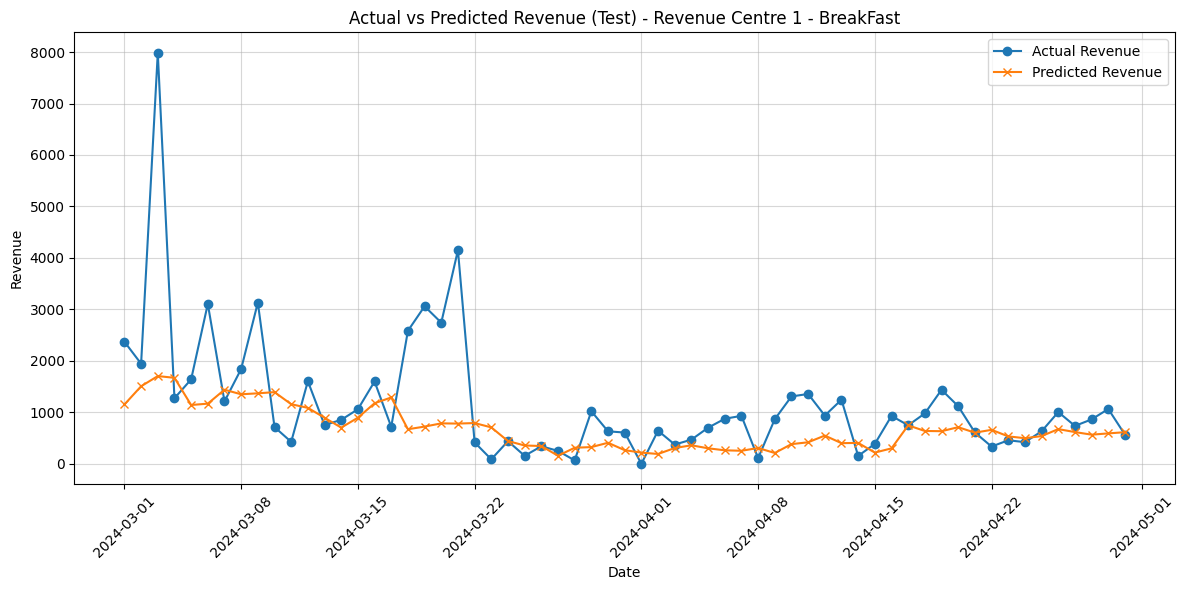

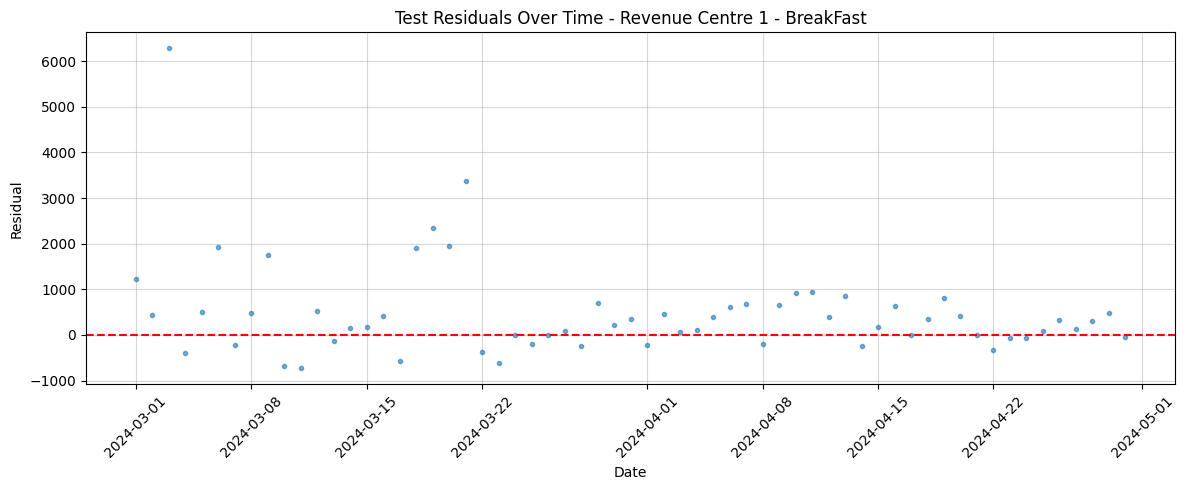

✅ Using Manual Params for Revenue Centre 1 - Dinner: LR=0.001, Units=64, Alpha=100.0
📊 Training Final Model for Revenue Centre 1 - Dinner (LR=0.001, Units=64, Alpha=100.0)
📈 Test Metrics for Revenue Centre 1 - Dinner: RMSE=1698.67, MAPE=40.55%


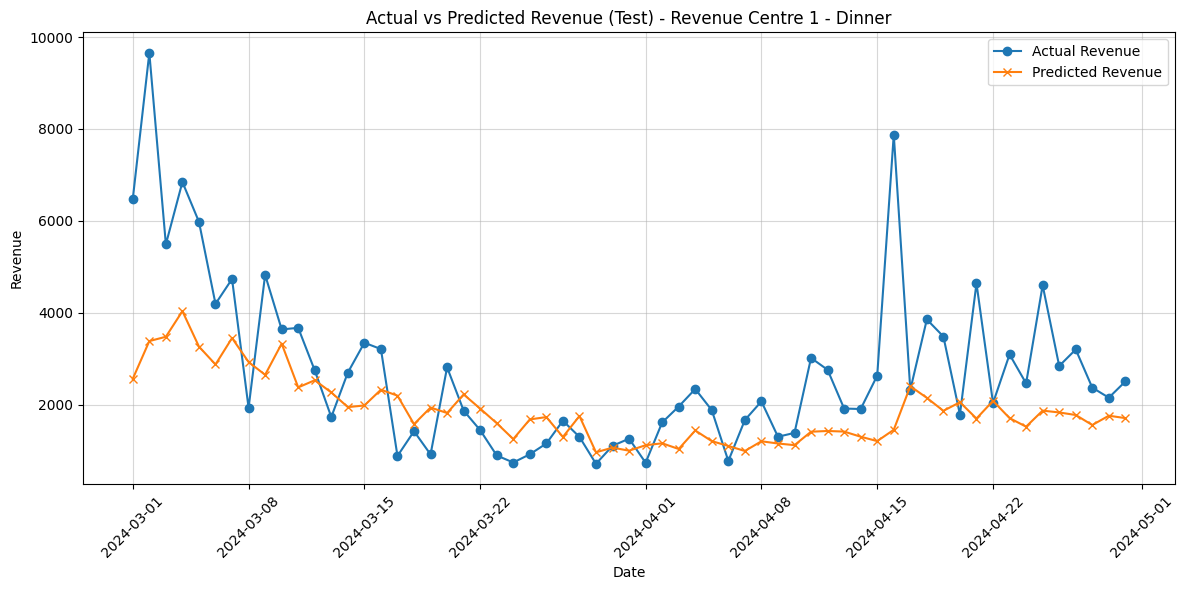

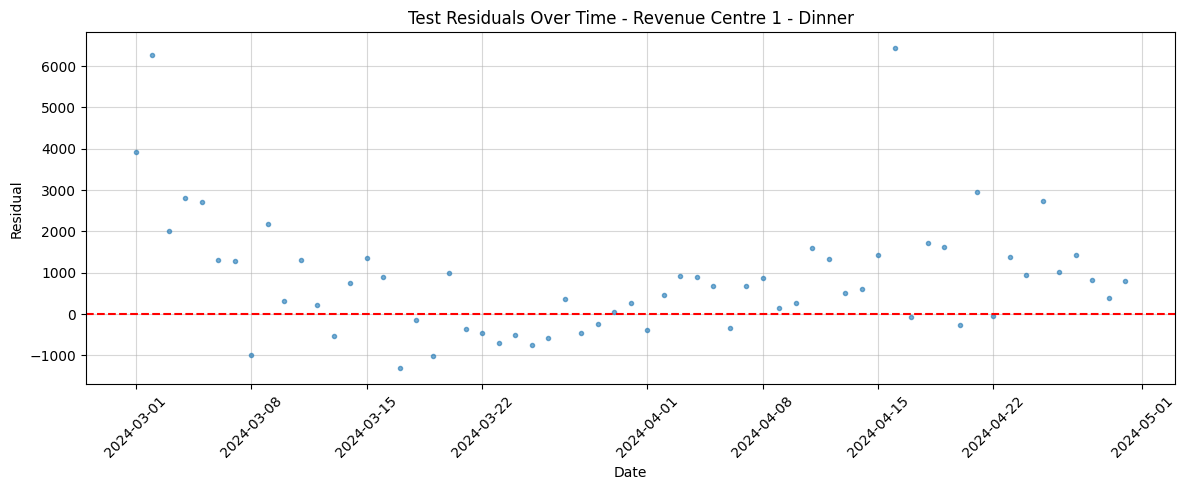

✅ Using Manual Params for Revenue Centre 1 - Lunch: LR=0.001, Units=64, Alpha=100.0
📊 Training Final Model for Revenue Centre 1 - Lunch (LR=0.001, Units=64, Alpha=100.0)
📈 Test Metrics for Revenue Centre 1 - Lunch: RMSE=622.42, MAPE=1134688058.96%


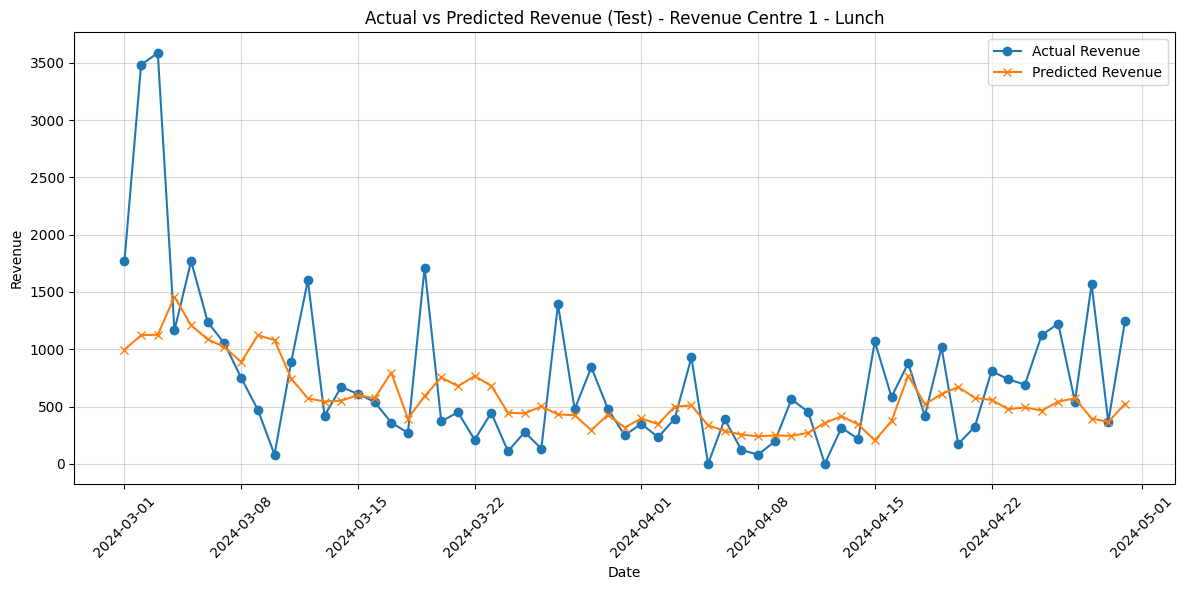

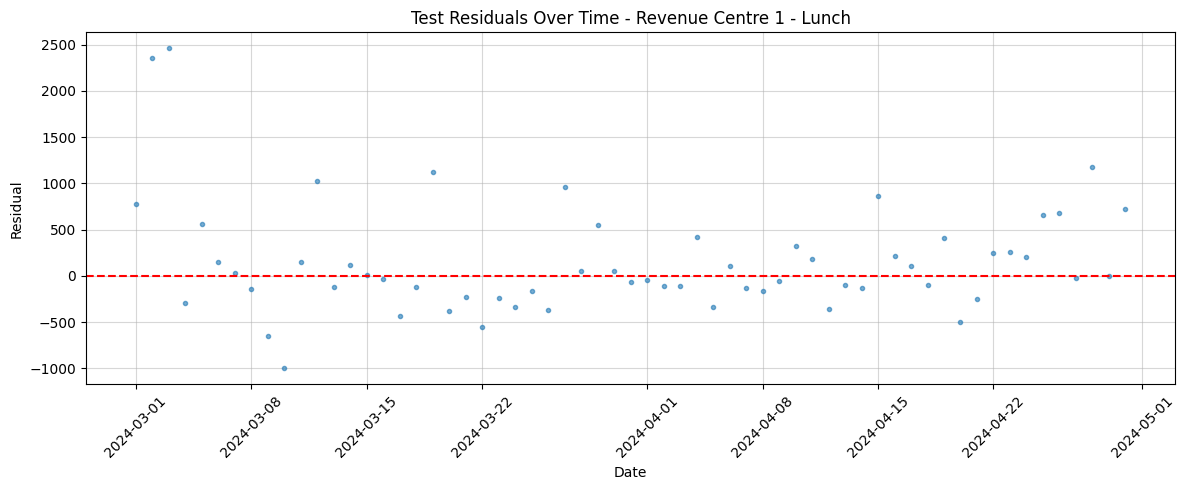

In [14]:
# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    """Load one center's sheet from Excel and parse Date column."""
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df


# ================== RUN ==================
if __name__ == '__main__':
    for center_id in range(0, 1):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            # Pass your chosen hyperparameters here
            train_and_plot_for_center(df_center, display_name,
                                      manual_lr=0.001, manual_units=64, manual_alpha=100.0,
                                      w_lstm=0.4, w_ridge=0.6)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")


In [15]:
!zip -r github_results.zip github_results
from google.colab import files
files.download("github_results.zip")

updating: github_results/ (stored 0%)
updating: github_results/Revenue_Centre_1_BreakFast_metrics.png (deflated 20%)
updating: github_results/Revenue_Centre_1_Lunch_metrics.png (deflated 20%)
updating: github_results/Revenue_Centre_1_summary.csv (deflated 43%)
updating: github_results/Revenue_Centre_1_Dinner_metrics.png (deflated 21%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>